# Nutritional Outlier Analysis (Strict Schema, PySpark)

This notebook detects foods with extreme values for key nutrients (e.g., highest sodium, protein, sugar per kcal) and provides recommendations for special dietary needs (iron/vitamin/protein deficiency, etc). Results are visualized and saved to output/NutritionalOutlierAnalysis.

In [1]:
# Imports and Spark session
from pyspark.sql import SparkSession, functions as F
import pandas as pd
import matplotlib.pyplot as plt
import os

# In cluster use the HDFS path prefix
path_prefix = "hdfs:///projects/BDA-12/"
# In local use the local path prefix
# path_prefix = "" 

spark = SparkSession.builder.appName("NutritionalOutlierAnalysis").getOrCreate()
print("Spark version:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/15 18:17:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0


In [2]:
# Configuration
input_path = f"{path_prefix}/output/nutritional_profiles"
output_dir = f"{path_prefix}/output/NutritionalOutlierAnalysis"
os.makedirs(output_dir, exist_ok=True)

# Strict schema mapping (edit as needed for your dataset)
schema_columns = {
    'id': 'fdc_id',
    'name': 'food_description',
    'category': 'food_type',
    'energy': 'energy',
    'protein': 'protein',
    'carb': 'carbs',
    'fat': 'total_fat',
    'fiber': 'fiber',
    'sugar': 'sugars',
    'saturated_fat': 'saturated_fat',
    'cholesterol': 'cholesterol',
    'sodium': 'sodium',
    'calcium': 'calcium',
    'iron': 'iron',
    'potassium': 'potassium',
    'vitamin_c': 'vitamin_c',
    'vitamin_a': 'vitamin_a',
    'vitamin_b12': 'vitamin_b12',
}

nutrient_cols = [
    'energy', 'protein', 'carb', 'fat', 'fiber', 'sugar', 'saturated_fat',
    'cholesterol', 'sodium', 'calcium', 'iron', 'potassium', 'vitamin_c', 'vitamin_a', 'vitamin_b12'
]

In [3]:
# Data loading with strict schema
from pyspark.sql.types import DoubleType

# Try to load the main Parquet file, fallback if not found
df = spark.read.parquet(input_path)

# Rename columns to strict schema
for std_col, orig_col in schema_columns.items():
    if orig_col in df.columns:
        df = df.withColumnRenamed(orig_col, std_col)

# Select only relevant columns
selected_cols = ['id', 'name', 'category'] + nutrient_cols
df = df.select(*[c for c in selected_cols if c in df.columns])

# Convert all nutrient columns to DoubleType
for col in nutrient_cols:
    if col in df.columns:
        df = df.withColumn(col, df[col].cast(DoubleType()))

df.cache()
df.show(5)

+------+--------------------+--------------+------+-------+-----+-----+-----+-----+-------------+-----------+------+-------+----+---------+---------+---------+-----------+
|    id|                name|      category|energy|protein| carb|  fat|fiber|sugar|saturated_fat|cholesterol|sodium|calcium|iron|potassium|vitamin_c|vitamin_a|vitamin_b12|
+------+--------------------+--------------+------+-------+-----+-----+-----+-----+-------------+-----------+------+-------+----+---------+---------+---------+-----------+
|167516|Waffles, buttermi...|sr_legacy_food|1144.0|   6.58|41.05| 9.22|  2.2|  4.3|        1.898|       15.0| 621.0|  279.0|6.04|    126.0|      0.0|    401.0|       2.86|
|167531|Crackers, cream, ...|sr_legacy_food|1941.0|   7.19|64.88| 19.5|  2.4|10.41|        2.634|       NULL| 752.0|  734.0|6.64|    117.0|     NULL|     NULL|        0.8|
|167540|Snacks, fruit lea...|sr_legacy_food|1504.0|    1.0|82.82| 2.68|  0.0|57.58|         0.65|        0.0| 199.0|   18.0|0.75|    164.0| 

## Outlier Detection for Key Nutrients

This section identifies foods with extreme (high or low) values for each key nutrient. Outliers are detected using the interquartile range (IQR) method for each nutrient. Results are shown for both high and low outliers, and can be used to inform dietary recommendations.

In [4]:
# Outlier detection using IQR for each nutrient
from pyspark.sql import functions as F

def get_outliers(df, col):
    # Calculate Q1 and Q3
    quantiles = df.approxQuantile(col, [0.25, 0.75], 0.01)
    if len(quantiles) < 2:
        return None, None, None, None
    Q1, Q3 = quantiles
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    high_outliers = df.filter(df[col] > upper).select('id', 'name', 'category', col)
    low_outliers = df.filter(df[col] < lower).select('id', 'name', 'category', col)
    return lower, upper, high_outliers, low_outliers

outlier_results = {}
for nutrient in nutrient_cols:
    if nutrient in df.columns:
        lower, upper, high, low = get_outliers(df, nutrient)
        outlier_results[nutrient] = {
            'lower': lower,
            'upper': upper,
            'high': high,
            'low': low
        }
        print(f"Nutrient: {nutrient}")
        print(f"  Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
        print(f"  High outliers: {high.count() if high else 0}, Low outliers: {low.count() if low else 0}")

Nutrient: energy
  Lower bound: -372.50, Upper bound: 863.50
  High outliers: 12355, Low outliers: 0
Nutrient: protein
  Lower bound: -15.14, Upper bound: 25.93
  High outliers: 65497, Low outliers: 0
Nutrient: carb
  Lower bound: -73.33, Upper bound: 140.00
  High outliers: 4593, Low outliers: 0
Nutrient: fat
  Lower bound: -28.50, Upper bound: 47.50
  High outliers: 74585, Low outliers: 0
Nutrient: fiber
  Lower bound: -5.40, Upper bound: 9.00
  High outliers: 115704, Low outliers: 0
Nutrient: sugar
  Lower bound: -31.47, Upper bound: 56.21
  High outliers: 126485, Low outliers: 0
Nutrient: saturated_fat
  Lower bound: -10.71, Upper bound: 17.85
  High outliers: 101269, Low outliers: 0
Nutrient: cholesterol
  Lower bound: -37.50, Upper bound: 62.50
  High outliers: 188448, Low outliers: 0
Nutrient: sodium
  Lower bound: -769.00, Upper bound: 1375.00
  High outliers: 113845, Low outliers: 0
Nutrient: calcium
  Lower bound: -157.50, Upper bound: 262.50
  High outliers: 128317, Low outl

## Visualize Outliers for Selected Nutrients

This section visualizes the foods with extreme (high/low) values for selected nutrients using bar charts. You can adjust the nutrient of interest to explore different outlier groups.

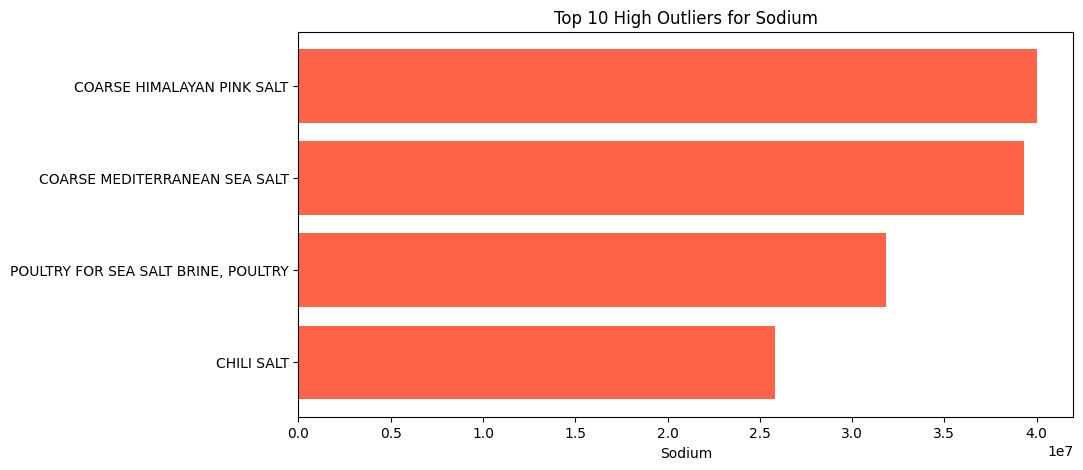

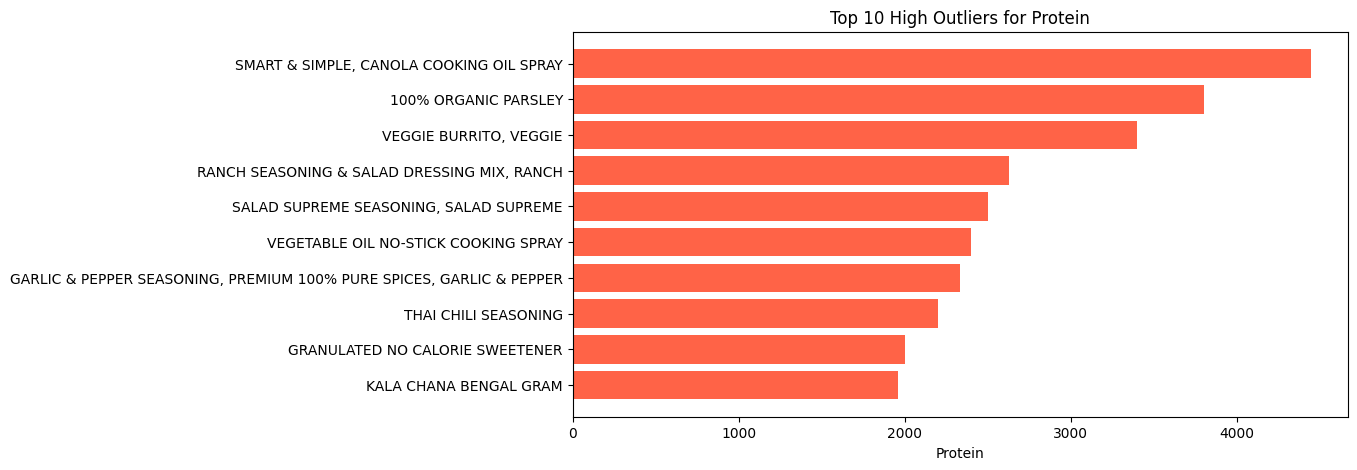

No low outliers for carb.


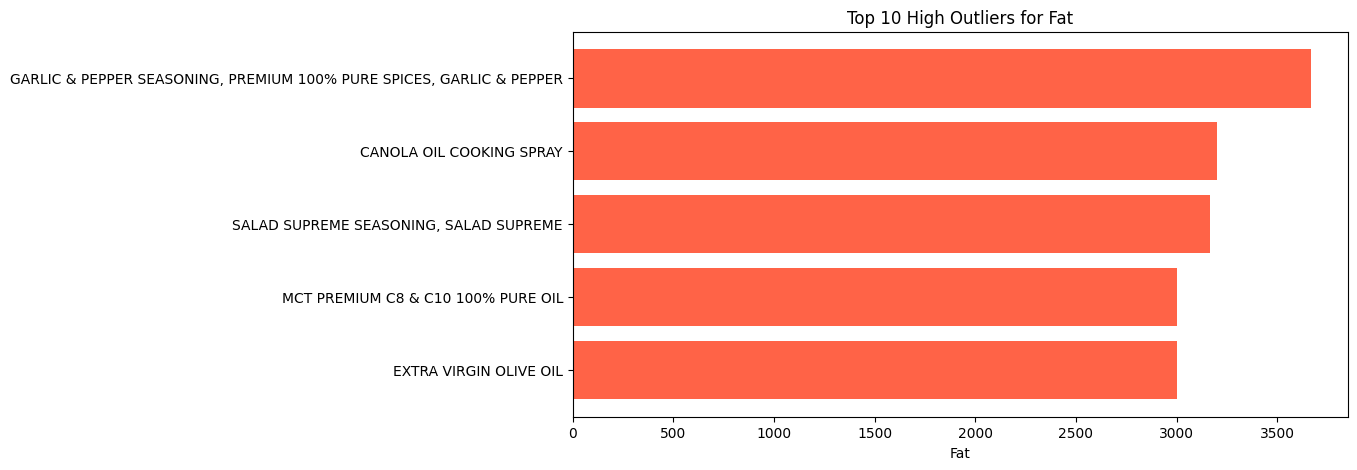

No low outliers for fiber.


In [5]:
# Visualization: Bar chart for high/low outliers of a selected nutrient
import matplotlib.pyplot as plt
import pandas as pd

def plot_outliers(nutrient, outlier_type='high', top_n=10):
    if nutrient not in outlier_results:
        print(f"Nutrient '{nutrient}' not found.")
        return
    sdf = outlier_results[nutrient][outlier_type]
    if sdf is None or sdf.count() == 0:
        print(f"No {outlier_type} outliers for {nutrient}.")
        return
    pdf = sdf.orderBy(F.desc(nutrient) if outlier_type=='high' else F.asc(nutrient)).limit(top_n).toPandas()
    plt.figure(figsize=(10, 5))
    plt.barh(pdf['name'], pdf[nutrient], color='tomato' if outlier_type=='high' else 'skyblue')
    plt.xlabel(nutrient.capitalize())
    plt.title(f"Top {top_n} {'High' if outlier_type=='high' else 'Low'} Outliers for {nutrient.capitalize()}")
    plt.gca().invert_yaxis()
    plt.show()

# Example: Plot high sodium outliers
plot_outliers('sodium', 'high', top_n=10)
# Example: Plot high protein outliers
plot_outliers('protein', 'high', top_n=10)

plot_outliers('carb', 'low', top_n=10)

plot_outliers('fat', 'high', top_n=10)

plot_outliers('fiber', 'low', top_n=10)


## Dietary Recommendations Based on Outlier Analysis

This section provides recommendations for foods suitable for special dietary needs (e.g., high iron for deficiency, low sodium for hypertension) by leveraging the detected outliers. You can adjust the logic to target specific nutrients or dietary goals.

Top 10 foods for iron deficiency:


,name,category,iron
0,"MINT CREME FILLED CHOCOLATE STICKS, MINT CREME",branded_food,769230.77
1,GARLIC SALT,branded_food,250000.00
2,GARLIC SALT,branded_food,250000.00
3,GARLIC SALT,branded_food,250000.00
4,GARLIC SALT,branded_food,250000.00
5,OVEN ROASTED TURKEY BREAST,branded_food,116071.43
6,"OVEN ROASTED FULLY COOKED TURKEY BREAST, OVEN ...",branded_food,116071.43
7,TAHINI SESAME SEED PASTE,branded_food,35714.29
8,TAHINI SESAME SEED PASTE,branded_food,35714.29
9,TAHINI SESAME SEED PASTE,branded_food,35714.29


Saved plot to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/iron_deficiency_recommendations.png


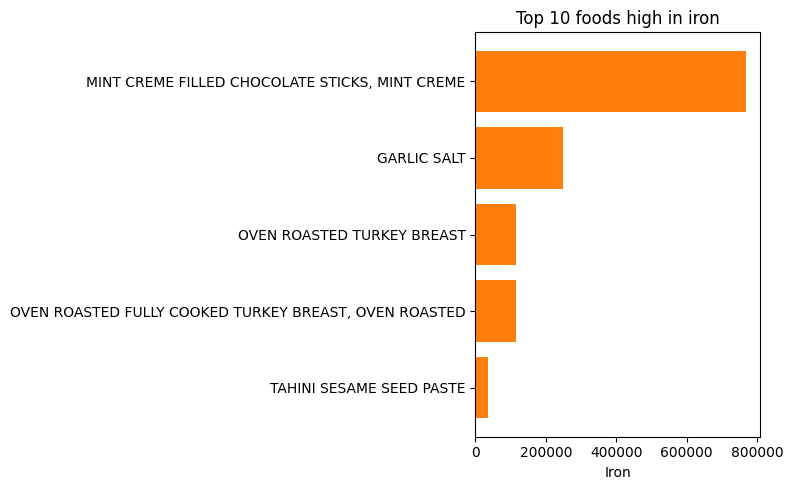

No low outliers for sodium.
No low outliers for fat.
No low outliers for carb.
Top 10 foods for protein deficiency:


,name,category,protein
0,"SMART & SIMPLE, CANOLA COOKING OIL SPRAY",branded_food,4444.44
1,100% ORGANIC PARSLEY,branded_food,3800.00
2,"VEGGIE BURRITO, VEGGIE",branded_food,3400.00
3,"RANCH SEASONING & SALAD DRESSING MIX, RANCH",branded_food,2625.00
4,"SALAD SUPREME SEASONING, SALAD SUPREME",branded_food,2500.00
5,VEGETABLE OIL NO-STICK COOKING SPRAY,branded_food,2400.00
6,"GARLIC & PEPPER SEASONING, PREMIUM 100% PURE S...",branded_food,2333.33
7,THAI CHILI SEASONING,branded_food,2200.00
8,GRANULATED NO CALORIE SWEETENER,branded_food,2000.00
9,KALA CHANA BENGAL GRAM,branded_food,1960.00


Saved plot to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/protein_deficiency_recommendations.png


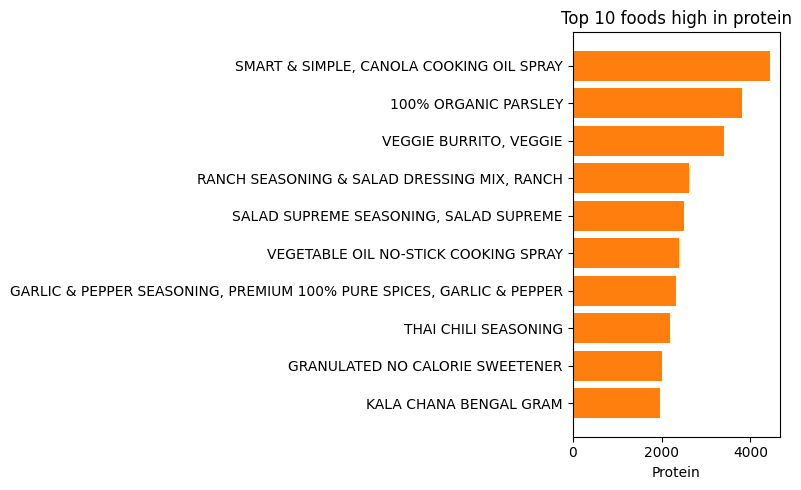

Top 10 foods for fiber deficiency:


,name,category,fiber
0,UNSWEETENED MUSHROOM BLEND COLD BREW BLACK COF...,branded_food,2468.9
1,KALA CHANA BENGAL GRAM,branded_food,1770.0
2,KALA CHANA BENGAL GRAM,branded_food,1770.0
3,KALA CHANA BENGAL GRAM,branded_food,1770.0
4,SOLUBLE COFFEE,branded_food,1730.0
5,"CAFE DE OLLA SOLUBLE COFFEE, CAFE DE OLLA",branded_food,1730.0
6,SOLUBLE COFFEE,branded_food,1730.0
7,SOLUBLE COFFEE,branded_food,1730.0
8,Hart Low Sodium Seasoned Refried Beans 112oz,branded_food,1200.0
9,Hart Low Sodium Seasoned Refried Beans 6 count...,branded_food,1200.0


Saved plot to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/fiber_deficiency_recommendations.png


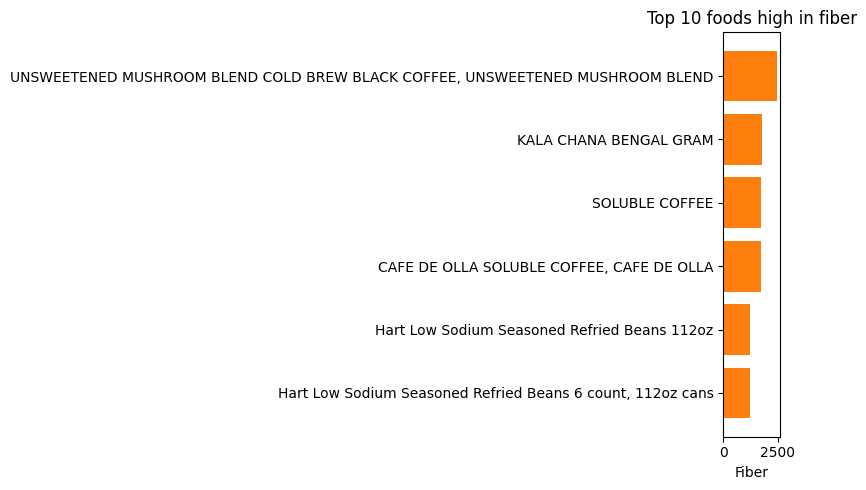

Top 10 foods for potassium deficiency:


,name,category,potassium
0,"RAW ITALIAN ALMOND BUTTER, RAW ITALIAN ALMOND",branded_food,7.500000e+09
1,FABULOUS FRIES,branded_food,4.000000e+06
2,FABULOUS FRIES,branded_food,4.000000e+06
3,FABULOUS FRIES,branded_food,4.000000e+06
4,FABULOUS FRIES,branded_food,4.000000e+06
5,"BACON FLAVOR BITS, BACON",branded_food,2.414286e+06
6,"BACON FLAVOR BITS, BACON",branded_food,2.414286e+06
7,"BACON FLAVOR BITS, BACON",branded_food,2.414286e+06
8,"GREEN TEA CARDAMOM BAGS, GREEN TEA CARDAMOM",branded_food,1.666667e+06
9,"MOROCCAN MINT GREEN TEA BAG, MOROCCAN MINT",branded_food,1.666667e+06


Saved plot to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/potassium_deficiency_recommendations.png


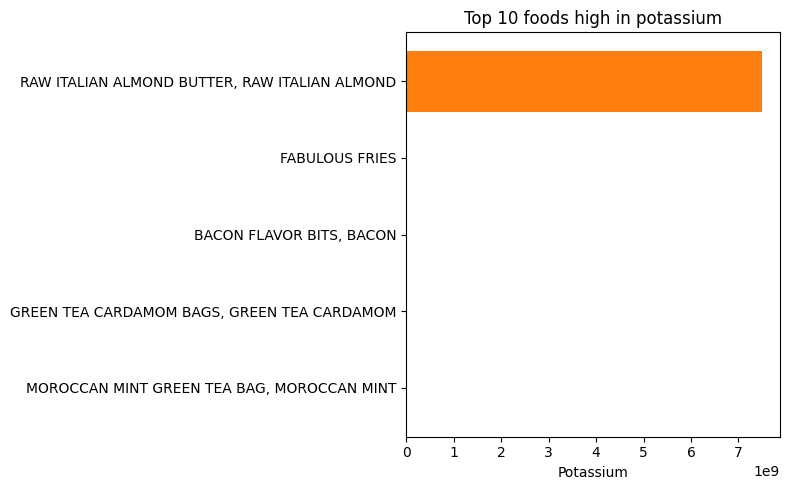

,id,name,category,potassium
0,934124,"RAW ITALIAN ALMOND BUTTER, RAW ITALIAN ALMOND",branded_food,7.500000e+09
1,1036761,FABULOUS FRIES,branded_food,4.000000e+06
2,2151056,FABULOUS FRIES,branded_food,4.000000e+06
3,923408,FABULOUS FRIES,branded_food,4.000000e+06
4,1710219,FABULOUS FRIES,branded_food,4.000000e+06
5,1387102,"BACON FLAVOR BITS, BACON",branded_food,2.414286e+06
6,1679343,"BACON FLAVOR BITS, BACON",branded_food,2.414286e+06
7,888630,"BACON FLAVOR BITS, BACON",branded_food,2.414286e+06
8,2538912,"GREEN TEA CARDAMOM BAGS, GREEN TEA CARDAMOM",branded_food,1.666667e+06
9,2538913,"MOROCCAN MINT GREEN TEA BAG, MOROCCAN MINT",branded_food,1.666667e+06


In [8]:
# Example recommendation logic for special dietary needs (with plots)
import matplotlib.pyplot as plt
import pandas as pd

def recommend_foods_for_deficiency(nutrient, top_n=10, plot=True, save=True):
    """Recommend foods high in a given nutrient (for deficiency).
    Produces a horizontal bar chart of the top foods and optionally saves it to the output directory."""
    if nutrient not in outlier_results:
        print(f"Nutrient '{nutrient}' not found.")
        return
    sdf = outlier_results[nutrient]['high']
    if sdf is None or sdf.count() == 0:
        print(f"No high outliers for {nutrient}.")
        return
    pdf = sdf.orderBy(F.desc(nutrient)).limit(top_n).toPandas()
    print(f"Top {top_n} foods for {nutrient} deficiency:")
    display(pdf[['name', 'category', nutrient]])

    if plot and not pdf.empty:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(pdf))))
        ax.barh(pdf['name'], pdf[nutrient], color='C1')
        ax.set_xlabel(nutrient.capitalize())
        ax.set_title(f"Top {top_n} foods high in {nutrient}")
        ax.invert_yaxis()
        plt.tight_layout()
        if save and 'output_dir' in globals():
            fname = f"{output_dir}/{nutrient}_deficiency_recommendations.png"
            fig.savefig(fname, dpi=150)
            print(f"Saved plot to {fname}")
        plt.show()

    return pdf

def recommend_foods_for_restriction(nutrient, top_n=10, plot=True, save=True):
    """Recommend foods low in a given nutrient (for restriction).
    Produces a horizontal bar chart of the top low-containing foods and optionally saves it to the output directory."""
    if nutrient not in outlier_results:
        print(f"Nutrient '{nutrient}' not found.")
        return
    sdf = outlier_results[nutrient]['low']
    if sdf is None or sdf.count() == 0:
        print(f"No low outliers for {nutrient}.")
        return
    pdf = sdf.orderBy(F.asc(nutrient)).limit(top_n).toPandas()
    print(f"Top {top_n} foods for {nutrient} restriction:")
    display(pdf[['name', 'category', nutrient]])

    if plot and not pdf.empty:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(pdf))))
        ax.barh(pdf['name'], pdf[nutrient], color='C0')
        ax.set_xlabel(nutrient.capitalize())
        ax.set_title(f"Top {top_n} foods low in {nutrient}")
        ax.invert_yaxis()
        plt.tight_layout()
        if save and 'output_dir' in globals():
            fname = f"{output_dir}/{nutrient}_restriction_recommendations.png"
            fig.savefig(fname, dpi=150)
            print(f"Saved plot to {fname}")
        plt.show()

    return pdf

# Example: Recommend foods for iron deficiency
recommend_foods_for_deficiency('iron', top_n=10)
# Example: Recommend foods for sodium restriction
recommend_foods_for_restriction('sodium', top_n=10)

recommend_foods_for_restriction('fat', top_n=10)

recommend_foods_for_restriction('carb', top_n=10)

recommend_foods_for_deficiency('protein', top_n=10)

recommend_foods_for_deficiency('fiber', top_n=10)

recommend_foods_for_deficiency('potassium', top_n=10)

## Save Outlier and Recommendation Results

This section saves the detected outlier foods and recommendations to CSV and Parquet files in the output/NutritionalOutlierAnalysis directory for further analysis or reporting.

In [7]:
# Save outlier results and recommendations to output directory (CSV only, no Parquet)
for nutrient, res in outlier_results.items():
    for outlier_type in ['high', 'low']:
        sdf = res[outlier_type]
        if sdf is not None and sdf.count() > 0:
            out_path_csv = f"{output_dir}/{nutrient}_{outlier_type}_outliers.csv"
            sdf.write.mode('overwrite').csv(out_path_csv, header=True)
            print(f"Saved {outlier_type} outliers for {nutrient} to {out_path_csv} ({sdf.count()} rows)")

# Example: Save iron deficiency and sodium restriction recommendations (CSV only)
iron_high = outlier_results['iron']['high']
sodium_low = outlier_results['sodium']['low']
if iron_high is not None and iron_high.count() > 0:
    iron_high.write.mode('overwrite').csv(f"{output_dir}/iron_deficiency_recommendations.csv", header=True)
    print(f"Saved iron deficiency recommendations to {output_dir}/iron_deficiency_recommendations.csv ({iron_high.count()} rows)")
if sodium_low is not None and sodium_low.count() > 0:
    sodium_low.write.mode('overwrite').csv(f"{output_dir}/sodium_restriction_recommendations.csv", header=True)
    print(f"Saved sodium restriction recommendations to {output_dir}/sodium_restriction_recommendations.csv ({sodium_low.count()} rows)")


Saved high outliers for energy to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/energy_high_outliers.csv (12355 rows)


Saved high outliers for protein to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/protein_high_outliers.csv (65497 rows)


Saved high outliers for carb to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/carb_high_outliers.csv (4593 rows)
Saved high outliers for fat to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/fat_high_outliers.csv (74585 rows)


Saved high outliers for fiber to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/fiber_high_outliers.csv (115704 rows)
Saved high outliers for sugar to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/sugar_high_outliers.csv (126485 rows)


Saved high outliers for saturated_fat to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/saturated_fat_high_outliers.csv (101269 rows)


Saved high outliers for cholesterol to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/cholesterol_high_outliers.csv (188448 rows)
Saved high outliers for sodium to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/sodium_high_outliers.csv (113845 rows)
Saved high outliers for calcium to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/calcium_high_outliers.csv (128317 rows)


Saved high outliers for iron to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/iron_high_outliers.csv (73757 rows)
Saved high outliers for potassium to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/potassium_high_outliers.csv (77445 rows)


Saved high outliers for vitamin_c to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/vitamin_c_high_outliers.csv (152798 rows)
Saved high outliers for vitamin_a to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/vitamin_a_high_outliers.csv (8767 rows)
Saved high outliers for vitamin_b12 to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/vitamin_b12_high_outliers.csv (7325 rows)
Saved iron deficiency recommendations to hdfs:///projects/BDA-12//output/NutritionalOutlierAnalysis/iron_deficiency_recommendations.csv (73757 rows)
